In [1]:
from dask.distributed import Client
client = Client(processes=False, n_workers=2, threads_per_worker=2)
#                 memory_limit='1GB')
client


Client Scheduler: inproc://192.168.0.17/6792/1 Dashboard: http://192.168.0.17:8787/status,Cluster Workers: 2 Cores: 4 Memory: 34.30 GB


In [ ]:
import os
os.chdir('../') # now  'src' folder

In [ ]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from dataset.toolwear import Toolwear
from tqdm import tqdm
import dask
import dask.dataframe as dd
import dask.array as da
import scaleogram as scg
import numpy as np
import xarray as xr
import pywt
import dask_image.ndfilters
import time
import dask.bag as db


In [ ]:
# # THIS FUNCTION TAKES TOO LONG
# FROM = 1
# TO = 16
# with tqdm(total=TO-FROM+1) as pbar:
#     for cut_no in range(FROM, TO+1):  
#         vib = Toolwear.batch_read(fpath=Path('D:/YandexDisk/machining/data/raw'),
#                                 cut_no=cut_no, kind='acc', n_cycle=200, interpolate=False)
#         df = dd.from_pandas(vib.reading.loc[:, ['time', 'data']], npartitions=4)
#         df.to_hdf(vib.path/'data.h5', key='/data')
#         del vib, df
#         gc.collect()
#         pbar.update(1)

In [ ]:
# # chunksize fix
# CUTNO = 14
# FS = 12800
# CHUNKSIZE = FS*2000
# dataframe = dd.read_hdf(Path('C:/Users/ugur/Documents/GitHub/ai-framework/input/machining_ssd_sample')/f'{CUTNO}'/'data_100xFs_copy.h5', key='/data', chunksize=CHUNKSIZE).compute()
# k = dataframe.shape[0]
# dataframe = dd.from_pandas(dataframe.loc[:k-k%CHUNKSIZE-1, :], chunksize=CHUNKSIZE)
# dataframe.to_hdf(Path('C:/Users/ugur/Documents/GitHub/ai-framework/input/machining_ssd_sample')/f'{CUTNO}'/'data_2000xFs.h5', 
#                  key='/data')

In [ ]:
# dataframes = dict()
# with tqdm(total=16) as pbar:
#     for cut_no in range(1, 17): 
#         df = dd.read_hdf(Path('D:/YandexDisk/machining/data/raw')/f'{cut_no}'/'data.h5', key='/data')
#         dataframes[cut_no] = df
#         pbar.update(1)

FS = 12800
CHUNKSIZE = FS*100
CUTNO=14

# dataframe = dd.read_hdf(Path('D:/YandexDisk/machining/data/raw')/f'{CUTNO}'/'data_100xFs.h5', key='/data', chunksize=CHUNKSIZE)
dataframe = dd.read_hdf(Path('C:/Users/ugur/Documents/GitHub/ai-framework/input/machining_ssd_sample')/f'{CUTNO}'/'data_2000xFs.h5', 
                        key='/data', 
                        chunksize=CHUNKSIZE)
dataframe.shape[0].compute()

In [ ]:
dataframe

# Datashader Part

In [ ]:
import datashader as ds
from datashader import transfer_functions as tf
import colorcet

In [ ]:
def plot_datashader(df):
    canvas = ds.Canvas(plot_width=600, plot_height=600, x_range=None, y_range=None, x_axis_type='linear', y_axis_type='linear')
    agg = canvas.points(df, 'time', 'data')
    img = tf.set_background(tf.shade(agg, cmap=colorcet.bmy), "white")
    return img

def plot_holoviews_datashade(df):
    import holoviews as hv
    from holoviews.operation.datashader import datashade
    hv.extension('bokeh')
    img = datashade(hv.Points(df, kdims=['time', 'data'])).opts(width=1000, height=400)
    return img

In [ ]:
# images = list()
# for cut_no, df in tqdm(dataframes.items()):
#     img = plot_datashader(df)
#     images.append(img)
# tf.Images(*images) 

In [ ]:
# tf.Images(*images).cols(6)

In [ ]:
img = plot_datashader(dataframe)

In [ ]:
img

In [ ]:
plot_holoviews_datashade(dataframe)

<img src="https://dpzbhybb2pdcj.cloudfront.net/daniel/Figures/c08_02.png" width="300"/>

In [ ]:
# import matplotlib.pyplot as plt
# %matplotlib inline
# plt.pcolormesh(time, scales, np.abs(cwt.coefs))

# Faster CWT with Dask

 ### Wrapper functions

In [ ]:
def fastcwt(data, scales, wavelet, sampling_period):
    out = np.zeros((np.size(scales), data.size), dtype=complex)
    precision = 10
    int_psi, x = pywt.integrate_wavelet(wavelet, precision=precision)

#     data = da.from_array(data, chunks=1024)
#     print(f"""
#     int_psi:{int_psi}
#     max:{int_psi.max()}
#     shape:{int_psi.shape}
#     """)
    for i in np.arange(np.size(scales)):
        step = x[1] - x[0]
        j = np.floor(np.arange(scales[i] * (x[-1] - x[0]) + 1) / (scales[i] * step))
        if np.max(j) >= np.size(int_psi):
            j = np.delete(j, np.where((j >= np.size(int_psi)))[0])
        
   
        int_psi_scale = int_psi[j.astype(np.int)][::-1]
        conv = np.convolve(data, int_psi_scale)
        

#         int_psi_scale = da.from_array(int_psi_scale, chunks=128)
        
#         conv = np.random.randn(data.shape[0] + int_psi_scale.shape[0] - 1)
#         print(conv.shape, conv2.shape, data.shape, int_psi_scale.shape)
        
#         conv = dask_image.ndfilters.convolve(input=data, weights=int_psi_scale).compute()
        
        coef = - np.sqrt(scales[i]) * np.diff(conv)
        
#         print(coef.shape, data.shape)
        d = (coef.size - data.size) / 2.
        if d > 0:
            out[i, :] = coef[int(np.floor(d)):int(-np.ceil(d))]
        elif d == 0.:
            out[i, :] = coef
        else:
            raise ValueError(
                "Selected scale of {} too small.".format(scales[i]))
    frequencies = pywt.scale2frequency(wavelet, scales, precision)
    frequencies = frequencies / sampling_period
    return out, frequencies

@dask.delayed
def calc_cwt(df):
    time = df['time'].values
    signal = df['data'].values
    wavelet='cmor6-1.5'
    dt = time[1] - time[0]
    scales = scg.periods2scales(np.logspace(start=0, stop=2.5, num=200), wavelet=wavelet) # dt param?

    # Calculate wavelet
    coefs, freqs = fastcwt(data=signal,
                  scales=scales,
                  wavelet=wavelet,
                 sampling_period=dt)
    return time, freqs, coefs



def calc_cwt_original(df):
    time = df['time'].values
    signal = df['data'].values
    wavelet='cmor6-1.5'
    dt = time[1] - time[0]

    scales = scg.periods2scales(np.logspace(start=0, stop=2.5, num=200), wavelet=wavelet) # dt param?

    coefs, freqs = scg.wfun.fastcwt(data=signal, scales=scales, 
                                    wavelet=wavelet, sampling_period=dt, 
                                    method='auto')
    return time, freqs, coefs



def assert_cwts():
    dfw = vib.reading.loc[0:0+12800*10-1, ['time', 'data']]
    _t = time.time()
    cwt = calc_cwt(dfw).compute()
    print(f"Custom_cwt: {time.time()-_t} sec")
    _t = time.time()
    cwt_original = calc_cwt_original(dfw)
    print(f"Orig_cwt: {time.time()-_t} sec")
    for param1, param2 in zip(cwt, cwt_original):
        print(param1.sum(), param2.sum())
#         assert param1.sum() == param2.sum()
#     print("Same function :)")
    
# assert_cwts()

### Data Initialization

In [ ]:
from dask.diagnostics import ProgressBar
wavelet='cmor6-1.5'
signal = dataframe['data'].to_dask_array(lengths=True)
t =      dataframe['time'].to_dask_array(lengths=True)
scales = scg.periods2scales(np.logspace(start=0, stop=2.5, num=20), wavelet=wavelet) # dt param?
# N = 12800*10
N = CHUNKSIZE


signal = signal[:N].rechunk(CHUNKSIZE)
t = t[:N].rechunk(CHUNKSIZE)

dataframe.head()

### Calculate Scales - maybe convert to dask.delayed?

In [ ]:
# - to be as large as the sum of data length and and maximum wavelet
#   support to avoid circular convolution effects
# - additional padding to reach a power of 2 for CPU-optimal FFT
size_pad = lambda s: 2**da.ceil(da.log2(s[0] + s[1])).astype(int)


### Coefs task graph with dask

In [ ]:

def get_int_psi_scales():
    precision = 10
    int_psi, x = pywt.integrate_wavelet(wavelet, precision=precision)
    int_psi_scales = list()
    for i in np.arange(scales.shape[0]):
        step = x[1] - x[0]
        j = da.floor(np.arange(scales[i] * (x[-1] - x[0]) + 1) / (scales[i] * step))
    #     if da.max(j) >= int_psi.shape[0]:
    #         j = np.delete(j, da.where((j >= int_psi.shape[0]))[0])

        j = j[j < int_psi.shape[0]] 
        int_psi_scale = int_psi[j.astype(int)][::-1]
        int_psi_scales.append(int_psi_scale)
    return np.array(int_psi_scales)




def dask_wavelet(int_psi_scale):
    size_scale = size_pad( (N, len(int_psi_scale)))
    nops_conv = N * len(int_psi_scale)
    nops_fft  = (3) * size_scale * da.log2(size_scale)
    if nops_fft < nops_conv:
        fft_data = da.fft.fft(signal, size_scale)
        fft_wav = da.fft.fft(int_psi_scale, size_scale)
        conv = da.fft.ifft(fft_wav*fft_data)
        conv = conv[0:N+len(int_psi_scale)-1]
    else:
        conv = dask_image.ndfilters.convolve(signal, int_psi_scale)
        
    coef = - da.sqrt(scales[i]) * da.diff(conv)
    d = (coef.shape[0]+1 - signal.shape[0]) / 2.
    if d > 0:
        coef = coef[int(np.floor(d)):int(-np.ceil(d))]
        
    return coef

In [ ]:
int_psi_scales = get_int_psi_scales()


In [ ]:
coefs = list()
for i, int_psi_scale in enumerate(int_psi_scales):
    scale_arr = da.from_array(int_psi_scale)
    coef = dask_wavelet(scale_arr)
    coefs.append(coef)

In [ ]:
size_scale = size_pad( (N, len(int_psi_scale)))
da.fft.fft(signal, size_scale)

### Collect dask results (Computational Expensive part)

In [ ]:
# Collect results
_t = time.time()
# b = db.from_delayed(coefs)
with ProgressBar():
    results = dask.compute(*coefs)

print(time.time()-_t)

In [ ]:
signal.chunks

### Draw wavelet

In [ ]:
# x, y = np.meshgrid(t, scales)
xarr = xr.DataArray(np.transpose(np.abs(results)), 
                    dims=['time', 'scales'], 
                    coords=[('time', t[:-1]),('scales', scales)], 
                    name='wavelet')
canvas = ds.Canvas()
img = tf.shade(canvas.quadmesh(xarr, x='time', y='scales'), cmap=colorcet.bgy, how='linear')
img

## Original method

In [ ]:
# signal_arr = signal.compute()
# t_arr = t.compute()

In [ ]:
# dt = t_arr[1] - t_arr[0]
# _t = time.time()
# scg.wfun.fastcwt(data=signal, scales=scales, 
#                                 wavelet=wavelet, sampling_period=dt, 
#                                 method='auto')
# print(time.time()-_t)

In [ ]:
# fs = 12800
# chunk_size = int(fs*0.1)  # means 1 seconds

In [ ]:
# xarrs = list()
# with tqdm(total=vib.reading.shape[0]//chunk_size+1) as pbar:
#     for ix in range(0, vib.reading.shape[0], chunk_size):
#         dfw = vib.reading.loc[ix:ix+chunk_size, ['time', 'data']]
#         xarr = calc_cwt(dfw)
#         xarrs.append(xarr)
#         pbar.update()
        

In [ ]:
# dfw = vib.reading.loc[0:0+chunk_size-1, ['time', 'data']]
# cwt = calc_cwt(dfw)

# time, scales, coefs = cwt
# x, y = np.meshgrid(time, scales)
# xarr = xr.DataArray(np.transpose(np.abs(coefs)), 
#                     coords=[('x', time), ('y', scales)], 
#                     dims=['time', 'scales'], name='wavelet')

In [ ]:
# # xarr.data.visualize()
# xarr = xarr.chunk({'time':100, 'scales':100})

In [ ]:
# xarr.data.visualize()

In [ ]:
# canvas = ds.Canvas()
# tf.shade(canvas.quadmesh(xarr.compute(), x='time', y='scales'), cmap=colorcet.bgy, how='linear')

In [ ]:
# wavelet_images = list()  
# with tqdm(total=vib.reading.shape[0]//chunk_size+1) as pbar:
#     for xarr in xarrs:
#         canvas = ds.Canvas()
#         img = tf.shade(canvas.quadmesh(xarr.compute(), x='time', y='scales'), cmap=colorcet.bgy, how='linear')
#         wavelet_images.append(img)
#         pbar.update()

In [ ]:
# tf.Images(*wavelet_images).cols(5)

In [ ]:
# xarr = xarrs[0]
# canvas = ds.Canvas()
# tf.shade(canvas.quadmesh(xarr.compute(), x='time', y='scales'), cmap=colorcet.bgy, how='linear')

# Datashader Quadmesh

In [ ]:
# x, y = np.meshgrid(time, scales)
# xarr = xr.DataArray(np.transpose(np.abs(cwt.coefs)), coords=[('x', time), ('y', scales)], dims=['time', 'scales'], name='wavelet')
    
# canvas = ds.Canvas(plot_width=600, plot_height=600, x_range=None, y_range=None, x_axis_type='linear', y_axis_type='linear')
# agg = canvas.quadmesh(xarr)
# img = tf.shade(agg)
# img

# Wavelet Function Refactoring with Dask

In [ ]:
# dt = time[1]-time[0]
# coefs, scales_freq = CWT_FUN(signal, scales, wavelet, dt)

In [ ]:
# fastcwt(data=signal, scales=scales, wavelet='cmor6-1.5', sampling_period=dt, method='auto')

In [ ]:
# import pywt
# pywt.ContinuousWavelet('cmor6-1.5').complex_cwt

# Random Dask Examples

In [ ]:
# import time
# import random

In [ ]:
# def costly_simulation(list_param):
#     time.sleep(random.random())
#     return sum(list_param)

In [ ]:
# %time costly_simulation([1, 2, 3, 4])

In [ ]:
# import pandas as pd
# import numpy as np

# input_params = pd.DataFrame(np.random.random(size=(500, 4)),
#                             columns=['param_a', 'param_b', 'param_c', 'param_d'])
# input_params.head()

In [ ]:
# %%time
# results = []
# for parameters in input_params.values:
#     result = costly_simulation(parameters)
#     results.append(result)

In [ ]:
# @dask.delayed
# def costly_simulation_dask(list_param):
#     time.sleep(random.random())
#     return sum(list_param)

In [ ]:
# %%time
# lazy_results = []
# for parameters in input_params.values:
#     result = costly_simulation_dask(parameters)
#     lazy_results.append(result)
# futures = lazy_results
# # futures = dask.persist(*lazy_results) # run in the background

In [ ]:
# %time dask.compute(*futures)

In [ ]:
# import dask.bag as db
# b = db.from_sequence(list(input_params.values), npartitions=100)
# b = b.map(costly_simulation)

In [ ]:
# %time results_bag = b.compute()

### pywt

In [2]:
import dask
import dask.dataframe as dd
import dask.array as da
from pathlib import Path
import pywt

In [3]:
FS = 12800
CHUNKSIZE = FS*100
CUTNO=14

# dataframe = dd.read_hdf(Path('D:/YandexDisk/machining/data/raw')/f'{CUTNO}'/'data_100xFs.h5', key='/data', chunksize=CHUNKSIZE)
dataframe = dd.read_hdf(Path('C:/Users/ugur/Documents/GitHub/ai-framework/input/machining_ssd_sample')/f'{CUTNO}'/'data_2000xFs.h5', 
                        key='/data', 
                        chunksize=CHUNKSIZE)

In [4]:
wavelet='cmor6-1.5'
signal = dataframe['data'].to_dask_array(lengths=True).compute()
t =      dataframe['time'].to_dask_array(lengths=True).compute()

signal = signal[:12]
t = t[:12]

signal = dask.delayed(signal)
t = dask.delayed(t)


In [5]:
import math
import scipy
import dask_image.ndfilters

def cwt(data, scales, wavelet, method='fft', axis=-1):
    powers = list()
    wavelet = pywt.DiscreteContinuousWavelet(wavelet)
    
    precision = 10
    int_psi, x = pywt.integrate_wavelet(wavelet, precision=precision)
    int_psi = np.conj(int_psi)

    # convert int_psi, x to the same precision as the data
    int_psi = np.asarray(int_psi, dtype=np.complex64)
    x = np.asarray(x, dtype=data.real.dtype)

    if method == 'fft':
        size_scale0 = -1
        fft_data = None
    elif not method == 'conv':
        raise ValueError("method must be 'conv' or 'fft'")

    for i, scale in enumerate(scales):
        step = x[1] - x[0]
        j = np.arange(scale * (x[-1] - x[0]) + 1) / (scale * step)
        j = j.astype(int)  # floor
        if j[-1] >= int_psi.size:
            j = np.extract(j < int_psi.size, j)
        int_psi_scale = int_psi[j][::-1]

        if method == 'conv':
            # check here
            conv = np.convolve(data, int_psi_scale)
#             conv = dask_image.ndfilters.convolve(data, int_psi_scale)
        else:
            # The padding is selected for:
            # - optimal FFT complexity
            # - to be larger than the two signals length to avoid circular
            #   convolution
            size_scale = scipy.fft.next_fast_len(
                data.shape[-1] + int_psi_scale.size - 1
            )
            if size_scale != size_scale0:
                # Must recompute fft_data when the padding size changes.
                fft_data = scipy.fft.fft(data, size_scale, axis=-1)
            size_scale0 = size_scale
            fft_wav = scipy.fft.fft(int_psi_scale, size_scale, axis=-1)
            conv = scipy.fft.ifft(fft_wav * fft_data, axis=-1)
            conv = conv[..., :data.shape[-1] + int_psi_scale.size - 1]

        coef = - np.sqrt(scale) * np.diff(conv, axis=-1)

        # transform axis is always -1 due to the data reshape above
        d = (coef.shape[-1]+1 - data.shape[-1]) / 2.
        if d > 0:
            coef = coef[..., math.floor(d):-math.ceil(d)]
        elif d < 0:
            raise ValueError("Selected scale of {} too small.".format(scale))
        
        power = ((abs(coef)) ** 2).astype(np.float32)
        powers.append(power)
    
    
    return da.stack(powers, axis=0)
#     return powers




In [6]:
def fake_cwt_iter(signal, scales, wavelet, method='conv'):
    return np.random.rand(len(signal) - 1, 1).reshape(-1).astype(np.float32)
   

In [17]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import numpy as np
import pywt

sampling_period = t[1] - t[0]
# Taken from http://nicolasfauchereau.github.io/climatecode/posts/wavelet-analysis-in-python/
wavelet = 'cmor1.5-1.0'
scales = np.arange(1, 5)

powers = list()
for i, scale in enumerate(scales):
    power = dask.delayed(fake_cwt_iter)(signal, scales, wavelet, method='conv')
    powers.append(dd.from_array(power))


frequencies = pywt.scale2frequency(pywt.DiscreteContinuousWavelet(wavelet), scales, 10) / sampling_period
period = 1. / frequencies
levels = [0.0625, 0.125, 0.25, 0.5, 1, 2, 4, 8]


TypeError: Truth of Delayed objects is not supported

In [ ]:
def writes():
    pass

In [14]:
total = dask.delayed(sum)(powers)

In [15]:
dd.from_delayed(total).compute()

distributed.worker - WARNING -  Compute Failed
Function:  check_meta
args:      (array([0.8962959 , 0.10201975, 0.16505167, 0.4583577 , 0.82278246,
       0.9969613 , 0.80122936, 0.6286479 , 0.8899542 , 0.7204971 ,
       0.51297617], dtype=float32), Series([], Name: 2, dtype: float32), 'from_delayed')
kwargs:    {}
Exception: ValueError('Metadata mismatch found in `from_delayed`.\n\nExpected partition of type `pandas.core.series.Series` but got `numpy.ndarray`')

distributed.worker - WARNING -  Compute Failed
Function:  check_meta
args:      (array([0.3850662 , 0.12701835, 0.5202316 , 0.6229939 , 0.50070333,
       0.5043954 , 0.24836169, 0.6804328 , 0.03946522, 0.38823128,
       0.27598226], dtype=float32), Series([], Name: 3, dtype: float32), 'from_delayed')
kwargs:    {}
Exception: ValueError('Metadata mismatch found in `from_delayed`.\n\nExpected partition of type `pandas.core.series.Series` but got `numpy.ndarray`')

distributed.worker - WARNING -  Compute Failed
Function:  chec

ValueError: Metadata mismatch found in `from_delayed`.

Expected partition of type `pandas.core.series.Series` but got `numpy.ndarray`

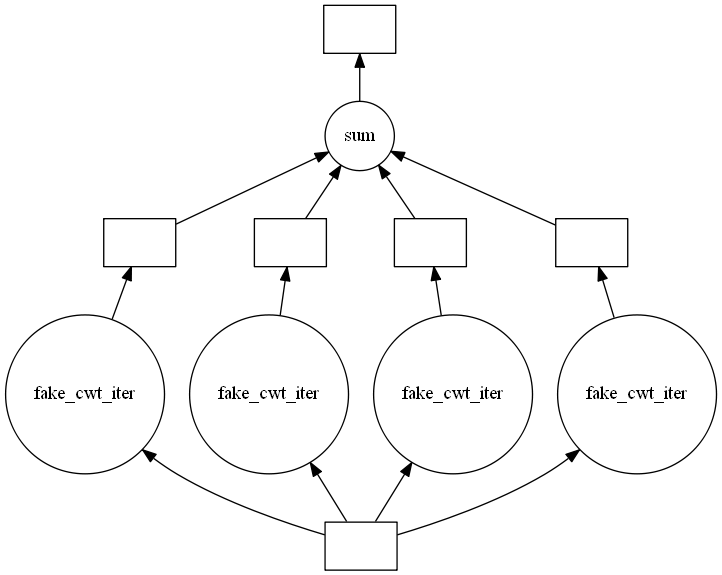

In [9]:
total.visualize()

In [ ]:
total.compute()

In [ ]:
import pandas as pd

In [ ]:
da.from_delayed(powers[0], len(signal)-1, dtype=np.float32)

In [ ]:
# c.to_dask(list(zip(c.columns, c.dtypes)))
df = dd.from_delayed(powers, meta=[(f"{scale:.2f}", np.float32) for scale in scales])
df

In [ ]:
df.shape[0].compute()

In [ ]:
dfs = df.to_delayed()

writes = [dask.delayed(save)(df, filename) for df,filename in zip(dfs, filenames)]

In [ ]:
df.shape[0].compute()

In [ ]:
arr = da.from_delayed(power, shape=(scales.shape[0], len(signal)-1), dtype=np.float32)
df = dd.from_array(arr)
# df = df.repartition(npartitions=128)
# df.to_hdf('data-sample.h5', '/data')



In [ ]:
CHUNKSIZE

In [ ]:
arr.rechunk((CHUNKSIZE//100, -1))

In [ ]:
df[:, [0, 1]].to_hdf('data-sample.h5', '/data')

In [ ]:
df.to_hdf

In [ ]:
# xarr = xr.DataArray(np.transpose(arr), 
#                     dims=['time', 'period'], 
#                     coords={'time': t[:-1], 
#                             'period': period}, 
#                     name='wavelet')



In [ ]:
import holoviews as hv
hv.extension('bokeh')
from holoviews.operation.datashader import datashade, shade, dynspread, rasterize
x_size = 100
y_size = 100
num_genes, num_samples = da_arr.shape

print("To Image..")
img = hv.Image((np.arange(num_samples), np.arange(num_genes), da_arr))
rasterized_img = rasterize(img, width=x_size, height=y_size)
rasterized_img.opts(width=x_size, height=y_size, cmap='viridis', logz=True)

hv.save(rasterized_img, "rasterized.png")

In [ ]:
img

In [ ]:
import datashader as ds
from datashader import transfer_functions as tf
import colorcet
import xarray as xr
# x, y = np.meshgrid(t, scales)

canvas = ds.Canvas()
img = tf.shade(canvas.quadmesh(xarr, x='time', y='period'), cmap=colorcet.bgy, how='linear')
img

In [ ]:
power.shape[0].compute()

In [ ]:
# f, ax = plt.subplots(figsize=(15, 10))
# ax.contourf(t, np.log2(period), np.log2(power), np.log2(levels),
#             extend='both')

# ax.set_title('%s Wavelet Power Spectrum (%s)' % ('Nino1+2', wavelet))
# ax.set_ylabel('Period (years)')
# Yticks = 2 ** np.arange(np.ceil(np.log2(period.min())),
#                         np.ceil(np.log2(period.max())))
# ax.set_yticks(np.log2(Yticks))
# ax.set_yticklabels(Yticks)
# ax.invert_yaxis()
# ylim = ax.get_ylim()
# # ax.set_ylim(ylim[0], -1)


In [ ]:
def f(x):
    return x

def batch(seq):
    sub_results = []
    for x in seq:
        sub_results.append(f(x))
    return sub_results

batches = []
for i in range(0, 10000000, 10000):
    result_batch = dask.delayed(batch)(range(i, i + 10000))
    batches.append(result_batch)

In [ ]:
import dask.bag as db
b = db.from_sequence(range(10000000), npartitions=1000)
b = b.map(f)

In [ ]:
dask.compute(*batches)

In [ ]:
dask.compute(*b)